Statistiken aus Roh-Daten, Datenexploration

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [17]:
VIDEO_DATA = "/Users/lmeyer/Programmierung DH/Projektarbeit_YT/converted_dataset/videos_all.parquet"
SPONSOR_CSV = "/Users/lmeyer/Programmierung DH/Projektarbeit_YT/raw_data/sb-mirror/sponsorTimes.csv"
CHANNEL_DATA = "/Users/lmeyer/Programmierung DH/Projektarbeit_YT/converted_dataset/channel_data_0000.parquet"

In [18]:
df_vid = pd.read_parquet(VIDEO_DATA, engine="fastparquet")
df_sb = pd.read_csv(SPONSOR_CSV, encoding="latin-1", on_bad_lines="skip", index_col="videoID")
df_channel = pd.read_parquet(CHANNEL_DATA)

/var/folders/7l/l25182_s0t37_pj4t5j47jyc0000gn/T/ipykernel_64843/2242119976.py:2: DtypeWarning: Columns (1,2,4,5,8,9,14,15,16,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sb = pd.read_csv(SPONSOR_CSV, encoding="latin-1", on_bad_lines="skip", index_col="videoID")


In [4]:
df_vid.set_index("id", inplace=True)
df_vid.index.names = ["videoID"]

In [20]:
display(df_vid.head())
display(df_sb.head())
display(df_channel.head())

,id,channel_id,channel_title,title,description,published_at,view_count,default_language,topic_categories,subtitles,...,snippet.thumbnails.medium.url,snippet.thumbnails.medium.width,snippet.thumbnails.standard.height,snippet.thumbnails.standard.url,snippet.thumbnails.standard.width,snippet.title,statistics.commentCount,statistics.favoriteCount,statistics.likeCount,statistics.viewCount
0,KX9r6Yg4P4A,UC_G9-FB6FFO7-SmBeyTOeBQ,CIVIL Solved,Calculating Coordinates in a Traverse using Mi...,This video explains the procedure of calculati...,2022-11-28T11:12:27Z,11710,en,[https://en.wikipedia.org/wiki/Knowledge],None,...,https://i.ytimg.com/vi/KX9r6Yg4P4A/mqdefault.jpg,320.0,480.0,https://i.ytimg.com/vi/KX9r6Yg4P4A/sddefault.jpg,640.0,Calculating Coordinates in a Traverse using Mi...,5,0,134,11710
1,KXA7ozurG-I,UC6ZFN9Tx6xh-skXCuRHCDpQ,PBS NewsHour,News Wrap: Trump suggests charging U.S. asylum...,"In our news wrap Tuesday, President Trump has ...",2019-04-30T22:20:17Z,4428,en,"[https://en.wikipedia.org/wiki/Politics, https...",None,...,https://i.ytimg.com/vi/KXA7ozurG-I/mqdefault.jpg,320.0,480.0,https://i.ytimg.com/vi/KXA7ozurG-I/sddefault.jpg,640.0,News Wrap: Trump suggests charging U.S. asylum...,None,0,113,4428
2,KXAGwkW_gMo,UCLnlD3yHgpji6fuEpNHE-yQ,Pihoozz,INTERVIEW GONE WRONG | Funny Shorts | PIHOOZZ,Ab isme meri kya galti? 🤔\n\nPihoozz\nThis is ...,2022-09-23T07:30:03Z,2814153,en,"[https://en.wikipedia.org/wiki/Entertainment, ...",None,...,https://i.ytimg.com/vi/KXAGwkW_gMo/mqdefault.jpg,320.0,480.0,https://i.ytimg.com/vi/KXAGwkW_gMo/sddefault.jpg,640.0,INTERVIEW GONE WRONG | Funny Shorts | PIHOOZZ,712,0,113331,2814153
3,KXAHHUpmBsI,UCinP-W0STEyduxxWCfwaQGA,りのしーGames【りのあとえーしー】,【OMORI】ボクはひきこもりのキミと旅をする #1【初見プレイ】,ずっとやりたかったOMORI！\n世界中から絶賛され日本語版をまだかまだかと待ち望まれていた...,2022-09-15T22:00:07Z,93,ja,"[https://en.wikipedia.org/wiki/Action_game, ht...",None,...,https://i.ytimg.com/vi/KXAHHUpmBsI/mqdefault.jpg,320.0,480.0,https://i.ytimg.com/vi/KXAHHUpmBsI/sddefault.jpg,640.0,【OMORI】ボクはひきこもりのキミと旅をする #1【初見プレイ】,2,0,12,93
4,KXARhThAzUw,UCDTINI9skkeZNY2ZXnBqIkQ,Eva zu Beck,I Took Him Backpacking for the First Time. Mis...,Thank you @ASUS for coming along on the journe...,2023-09-22T16:00:28Z,509375,en,"[https://en.wikipedia.org/wiki/Hobby, https://...",None,...,https://i.ytimg.com/vi/KXARhThAzUw/mqdefault.jpg,320.0,480.0,https://i.ytimg.com/vi/KXARhThAzUw/sddefault.jpg,640.0,I Took Him Backpacking for the First Time. Mis...,1311,0,18952,509375


,startTime,endTime,votes,locked,incorrectVotes,UUID,userID,timeSubmitted,views,category,actionType,service,videoDuration,hidden,reputation,shadowHidden,hashedVideoID,userAgent,description
videoID,,,,,,,,,,,,,,,,,,,
UjtOGPJ0URM,497.1431,569.1533,-2,0,1,b3237a80-a2c3-11e9-b210-99c885575bb9,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,24217,sponsor,skip,YouTube,0.0,0,0,0,03224876b002487796379942f199bc22ffac46157ad248...,NaN,NaN
FfgT6zx4k3Q,446.51013,513.39233,225,0,1,96150fa0-a28a-11e9-b210-99c885575bb9,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,3222,sponsor,skip,YouTube,0.0,1,0,0,0bfebefdc667735b19d5f2630e7e83a5f7fdddb880534e...,NaN,NaN
fBxtS9BpVWs,41.0,53.0,115,0,1,b2465943-1313-449c-b75c-08b14756ac0a,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,772,sponsor,skip,YouTube,0.0,0,0,0,bdd81b2b8192683242fe3608c45d5b958ddc71e9b2981a...,NaN,NaN
9P6rdqiybaw,488.5215,542.11035,-2,0,1,81024780-a367-11e9-b256-cb886cabe693,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,25661,sponsor,skip,YouTube,552.0,0,0,0,cc9cd26ee245cb89f2be13d047de8ea1a642c8f56bcb6e...,NaN,NaN
ulCdoCfw-bY,487.50198,547.4875,-2,0,1,16090680-a367-11e9-b256-cb886cabe693,38e7c2af-09f4-4492-bf49-75e443962ccd,1564088876715,26984,sponsor,skip,YouTube,0.0,0,0,0,177779136cde894988da5e2d3160ef38d302a8554d710d...,NaN,NaN


,id,channel_title,channel_description,channel_handle,channel_country,channel_topic_ids,channel_topic_categories,channel_snippet,channel_statistics
0,UCQs6Vkvy2h6vMcz4amPWUhA,Instagrafia,Hey in this channel we bring you the latest fa...,@instagrafia,IN,"[/m/032tl, /m/019_rr]","[https://en.wikipedia.org/wiki/Fashion, https:...","{'country': 'IN', 'customUrl': '@instagrafia',...","{'hiddenSubscriberCount': False, 'subscriberCo..."
1,UCVI-gmqb3PhWwecTigx8P7Q,Rina Sawayama,💥Official YouTube channel of Rina Sawayama💥 \n...,@rinasawayamaofficial,GB,"[/m/04rlf, /m/064t9, /m/02jjt, /m/02lkt, /m/02...","[https://en.wikipedia.org/wiki/Music, https://...","{'country': 'GB', 'customUrl': '@rinasawayamao...","{'hiddenSubscriberCount': False, 'subscriberCo..."
2,UCla3r8QMYO9uT9lN55ZOQNQ,Rad Dad's Print Lab,Just a Dad who enjoys 3d printing and making s...,@raddadsprintlab,US,"[/m/03glg, /m/019_rr, /m/07c1v]","[https://en.wikipedia.org/wiki/Hobby, https://...","{'country': 'US', 'customUrl': '@raddadsprintl...","{'hiddenSubscriberCount': False, 'subscriberCo..."
3,UCvOU-zTlankT-JjN3ZzvuKA,Podcastage,Podcastage is a youtube channel that provides ...,@podcastage,US,"[/m/07c1v, /m/019_rr]","[https://en.wikipedia.org/wiki/Technology, htt...","{'country': 'US', 'customUrl': '@podcastage', ...","{'hiddenSubscriberCount': False, 'subscriberCo..."
4,UCNsNMUpPrKOtd6DBPtwNa9w,The World Of Science,We Make People Fall In Love With Space & Scien...,@theworldofscienceco,IN,[/m/01k8wb],[https://en.wikipedia.org/wiki/Knowledge],"{'country': 'IN', 'customUrl': '@theworldofsci...","{'hiddenSubscriberCount': False, 'subscriberCo..."


## Common Categories

In [46]:
l=[]
for cat in df_vid["topic_categories"]:
    if cat is not None:
        for c in cat:
            l.append(c.replace("https://en.wikipedia.org/wiki/",""))

c = Counter(l)
            
common_categories = pd.DataFrame(c.items(), columns=['item', 'count'])

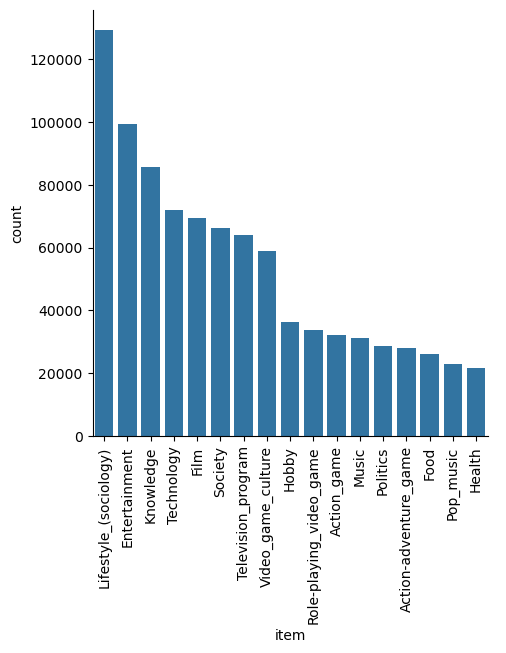

In [57]:
common_categories.sort_values("count", inplace=True, ascending=False)
mask_large_cats = common_categories["count"] > 20_000
sns.catplot(common_categories[mask_large_cats], x="item", y="count", kind="bar")
plt.xticks(rotation=90)
plt.show()

## Common Channels

/Users/lmeyer/micromamba/envs/studium/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/Users/lmeyer/micromamba/envs/studium/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 22855 (\N{CJK UNIFIED IDEOGRAPH-5947}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/Users/lmeyer/micromamba/envs/studium/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 33402 (\N{CJK UNIFIED IDEOGRAPH-827A}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/Users/lmeyer/micromamba/envs/studium/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/lmeyer/micromamba/envs/studium/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22855 

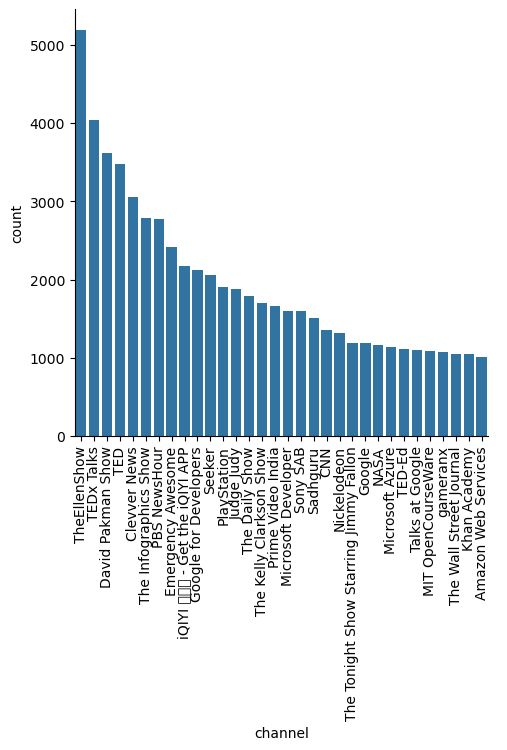

In [21]:
all_channels = [chan for chan in df_vid["channel_title"]]

c_chan = Counter(all_channels)

common_channels = pd.DataFrame(c_chan.items(), columns = ["channel","count"])

common_channels.sort_values("count", inplace=True, ascending=False)
common_channels_mask = common_channels["count"] > 1_000

sns.catplot(common_channels[common_channels_mask], x="channel", y="count", kind="bar")
plt.xticks(rotation=90)
plt.show()